# 03 — Baselines & Leak-Free Comparison Harness (Gemcitabine)

This notebook builds the modelling foundation. Everything here is **leak-free**:
scaling and feature selection are fit **inside each CV fold only**.

**Driving question — the tissue confound.** The PCA in notebook 02 showed blood cancers
(myeloid + lymphoid) form a distinct, more-sensitive cluster. Tissue type therefore predicts
*both* the expression profile and the IC50. So before claiming "genes predict drug response"
we must ask: **how much is just tissue, and what do genes add on top?**

We answer this with a comparison harness, all under the same 5-fold stratified CV:

| # | Model | What it tells us |
|---|---|---|
| 0 | Lineage-only → Ridge | The confound baseline — signal from tissue alone |
| 1 | All genes → Ridge | Sound linear model for p≫n; discards nothing |
| 2 | Top-N genes (MI) → Ridge | Interpretable subset; sweep N |
| 3 | ElasticNetCV | Embedded selection; can see past the lineage shortcut |
| — | PCA-50 → Ridge | Representation contrast (loses gene interpretability) |

We then break performance down **by lineage** and re-run on **solid tumours only** (blood
cancers removed) to check the model learned *mechanism*, not the *blood = sensitive* shortcut.

The notebook persists arrays (`X`, `y`, folds, selected genes) to `output/` so notebooks 04–05
load instantly without re-reading the 518 MB expression matrix.

---
## Section 0 — Imports & Config

In [1]:
import os, json, time, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import VarianceThreshold, mutual_info_regression
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import RidgeCV, ElasticNetCV
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import r2_score, mean_squared_error

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.float_format", "{:.4f}".format)

DATA_DIR  = "../data/"
GDSC_PATH  = DATA_DIR + "GDSC2_fitted_dose_response_27Oct23.csv"
MODEL_PATH = DATA_DIR + "Model.csv"
EXPR_PATH  = DATA_DIR + "OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv"

OUTPUT_DIR = "../output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Hyperparameters
VARIANCE_THRESHOLD = 0.1
MIN_LINEAGE_COUNT  = 5
N_SPLITS           = 5
RANDOM_SEED        = 42
KS                 = [500, 1000, 2000]      # top-N gene sweep
RIDGE_ALPHAS       = np.logspace(-1, 4, 10)
TARGET_DRUG        = "Gemcitabine"
BLOOD_LINEAGES     = ["Lymphoid", "Myeloid"]

rng = np.random.RandomState(RANDOM_SEED)
print("Setup complete. Output ->", os.path.abspath(OUTPUT_DIR))

Setup complete. Output -> /app/output


---
## Section 1 — Rebuild Merge & Variance Filter

Replicates notebook 02 (Sections 1–4) exactly: 3-way merge, dedup by
`['COSMIC_ID','DRUG_NAME','ModelID']` only, filter expression to
`IsDefaultEntryForModel == 'Yes'`, then drop genes with variance < 0.1.

> **Note on leakage:** the variance filter uses only `X` (not `y`), so applying it once on all
> data is fine. Label-aware steps (MI selection, scaling) happen *inside folds* later.

In [2]:
# 1a. GDSC2
gdsc = pd.read_csv(GDSC_PATH)

# 1b. Model.csv -> clean COSMIC_ID
model = pd.read_csv(MODEL_PATH, low_memory=False)
model_clean = (
    model[["ModelID", "CellLineName", "COSMICID", "OncotreeLineage"]]
    .rename(columns={"COSMICID": "COSMIC_ID"})
    .dropna(subset=["COSMIC_ID"]).copy()
)
model_clean["COSMIC_ID"] = model_clean["COSMIC_ID"].astype(int)

# 1c. Expression -> default entries only
print("Loading expression matrix (~30s)...")
expr_raw = pd.read_csv(EXPR_PATH)
if expr_raw.columns[0].startswith("Unnamed"):
    expr_raw = expr_raw.drop(columns=[expr_raw.columns[0]])
expr = expr_raw[expr_raw["IsDefaultEntryForModel"] == "Yes"].copy()
meta_cols = ["ModelID", "SequencingID", "IsDefaultEntryForModel",
             "ModelConditionID", "IsDefaultEntryForMC"]
gene_cols = [c for c in expr.columns if c not in meta_cols]
expr_final = expr[["ModelID"] + gene_cols].copy()

# 1d. Join + filter to target drug + dedup
gdsc_model = gdsc.merge(model_clean, on="COSMIC_ID", how="inner")
gdsc_model = gdsc_model[gdsc_model["ModelID"].isin(set(expr_final["ModelID"]))].copy()
gem = gdsc_model[gdsc_model["DRUG_NAME"] == TARGET_DRUG].copy()
target_df = (
    gem.groupby(["COSMIC_ID", "DRUG_NAME", "ModelID"], as_index=False)
       .agg(CellLineName=("CellLineName", "first"),
            OncotreeLineage=("OncotreeLineage", "first"),
            TCGA_DESC=("TCGA_DESC", "first"),
            LN_IC50=("LN_IC50", "mean"))
)

merged = target_df.merge(expr_final, on="ModelID", how="inner")
gene_cols_present = [c for c in gene_cols if c in merged.columns]

X_raw = merged[gene_cols_present].values.astype(np.float32)
y     = merged["LN_IC50"].values.astype(np.float32)
meta  = merged[["ModelID", "COSMIC_ID", "CellLineName", "OncotreeLineage", "TCGA_DESC"]].copy()

# Variance filter (unsupervised)
vt = VarianceThreshold(VARIANCE_THRESHOLD).fit(X_raw)
keep_mask  = vt.get_support()
gene_names = [gene_cols_present[i] for i in range(len(keep_mask)) if keep_mask[i]]
X = X_raw[:, keep_mask].astype(np.float32)

print(f"Cell lines: {X.shape[0]}  |  genes after variance filter: {X.shape[1]}")
print(f"y: mean={y.mean():.3f}, std={y.std():.3f}, range=[{y.min():.2f}, {y.max():.2f}]")

Loading expression matrix (~30s)...


Cell lines: 694  |  genes after variance filter: 16820
y: mean=-0.629, std=3.032, range=[-6.34, 7.72]


---
## Section 2 — Lineage Labels & Stratified Splits

`OncotreeLineage` drives stratification (it has no nulls after fillna, unlike `TCGA_DESC`).
Rare lineages (< 5 cell lines) are collapsed to `"Other"` so every class survives a 5-fold
split. We persist the fold indices and an 80/20 holdout so notebooks 04–05 use identical splits.

In [3]:
def collapse_rare(labels, min_count=MIN_LINEAGE_COUNT):
    s = pd.Series(labels).fillna("Unknown")
    counts = s.value_counts()
    rare = counts[counts < min_count].index
    return s.where(~s.isin(rare), "Other").values

lineage_label   = collapse_rare(meta["OncotreeLineage"].values)
le              = LabelEncoder()
lineage_encoded = le.fit_transform(lineage_label)
meta["lineage_label"]   = lineage_label
meta["lineage_encoded"] = lineage_encoded
meta["is_blood"]        = np.isin(lineage_label, BLOOD_LINEAGES)

print(f"Lineage classes: {len(le.classes_)}")
print(f"Blood-cancer cell lines: {meta['is_blood'].sum()} / {len(meta)}")

# 5-fold stratified CV
skf   = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_SEED)
folds = list(skf.split(X, lineage_encoded))

# 80/20 stratified holdout (for fitting final models in nb 04/05)
holdout_train_idx, holdout_test_idx = train_test_split(
    np.arange(len(y)), test_size=0.2, stratify=lineage_encoded, random_state=RANDOM_SEED)

# Persist everything downstream notebooks need (output/ is gitignored)
np.save(os.path.join(OUTPUT_DIR, "X_var_filtered.npy"), X)
np.save(os.path.join(OUTPUT_DIR, "y.npy"), y)
with open(os.path.join(OUTPUT_DIR, "gene_names.json"), "w") as f:
    json.dump(gene_names, f)
meta.to_csv(os.path.join(OUTPUT_DIR, "meta.csv"), index=False)
np.savez(os.path.join(OUTPUT_DIR, "cv_folds.npz"),
         **{f"train_{i}": tr for i, (tr, te) in enumerate(folds)},
         **{f"test_{i}": te for i, (tr, te) in enumerate(folds)})
np.savez(os.path.join(OUTPUT_DIR, "holdout_split.npz"),
         train=holdout_train_idx, test=holdout_test_idx)
print("Saved X/y/folds/meta to output/.")

Lineage classes: 23
Blood-cancer cell lines: 115 / 694


Saved X/y/folds/meta to output/.


---
## Section 3 — Run the Comparison Harness

Manual CV loop so we can (a) compute mutual information **once per fold** and reuse it across
all `k`, (b) collect out-of-fold predictions for pooled + per-lineage metrics. Every label-aware
transform (`StandardScaler`, `mutual_info_regression`, `RidgeCV`, `ElasticNetCV`, `PCA`) is fit on
the **training fold only**.

In [4]:
model_names = (["Lineage-only (Ridge)", "All genes (Ridge)"]
               + [f"Top-{k} MI (Ridge)" for k in KS]
               + ["ElasticNetCV", "PCA-50 (Ridge)"])

n = X.shape[0]
oof          = {m: np.full(n, np.nan) for m in model_names}
fold_metrics = {m: [] for m in model_names}     # (rmse, r2, pearson_r) per fold
selected_idx = {k: [] for k in KS}              # selected gene indices per fold

def _rmse(yt, yp):
    return float(np.sqrt(mean_squared_error(yt, yp)))

def record(name, te, yt, pred):
    oof[name][te] = pred
    fold_metrics[name].append(
        (_rmse(yt, pred), r2_score(yt, pred), float(np.corrcoef(yt, pred)[0, 1])))

for fi, (tr, te) in enumerate(folds, 1):
    t0 = time.time()
    Xtr, Xte = X[tr], X[te]
    ytr, yte = y[tr], y[te]
    lin_tr, lin_te = lineage_encoded[tr].reshape(-1, 1), lineage_encoded[te].reshape(-1, 1)

    scaler = StandardScaler().fit(Xtr)
    Xtr_s, Xte_s = scaler.transform(Xtr), scaler.transform(Xte)

    # 0 — lineage only
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False).fit(lin_tr)
    m0 = RidgeCV(alphas=RIDGE_ALPHAS).fit(ohe.transform(lin_tr), ytr)
    record("Lineage-only (Ridge)", te, yte, m0.predict(ohe.transform(lin_te)))

    # 1 — all genes
    m1 = RidgeCV(alphas=RIDGE_ALPHAS).fit(Xtr_s, ytr)
    record("All genes (Ridge)", te, yte, m1.predict(Xte_s))

    # 2 — top-N MI (compute MI once, reuse for every k)
    mi    = mutual_info_regression(Xtr_s, ytr, random_state=RANDOM_SEED)
    order = np.argsort(mi)[::-1]
    for k in KS:
        idx = order[:k]
        selected_idx[k].append(idx)
        mk = RidgeCV(alphas=RIDGE_ALPHAS).fit(Xtr_s[:, idx], ytr)
        record(f"Top-{k} MI (Ridge)", te, yte, mk.predict(Xte_s[:, idx]))

    # 3 — ElasticNetCV (embedded selection)
    enet = ElasticNetCV(l1_ratio=0.5, n_alphas=20, cv=3, max_iter=2000, tol=1e-2,
                        random_state=RANDOM_SEED, n_jobs=-1, selection="random").fit(Xtr_s, ytr)
    record("ElasticNetCV", te, yte, enet.predict(Xte_s))

    # PCA contrast
    pca = PCA(n_components=50, random_state=RANDOM_SEED).fit(Xtr_s)
    mp  = RidgeCV(alphas=RIDGE_ALPHAS).fit(pca.transform(Xtr_s), ytr)
    record("PCA-50 (Ridge)", te, yte, mp.predict(pca.transform(Xte_s)))

    print(f"Fold {fi}/{N_SPLITS} done in {time.time()-t0:.0f}s")

print("Harness complete.")

Fold 1/5 done in 43s


Fold 2/5 done in 45s


Fold 3/5 done in 45s


Fold 4/5 done in 43s


Fold 5/5 done in 43s
Harness complete.


---
## Section 4 — Results Table

Mean ± std across folds, plus pooled out-of-fold R² (a single honest estimate on all 694).

In [5]:
rows = []
for m in model_names:
    arr = np.array(fold_metrics[m])                       # (n_folds, 3)
    rows.append({
        "model": m,
        "RMSE_mean": arr[:, 0].mean(), "RMSE_std": arr[:, 0].std(),
        "R2_mean":   arr[:, 1].mean(), "R2_std":   arr[:, 1].std(),
        "PearsonR_mean": arr[:, 2].mean(),
        "R2_pooled_oof": r2_score(y, oof[m]),
    })
comparison = pd.DataFrame(rows).sort_values("R2_pooled_oof", ascending=False).reset_index(drop=True)
comparison.to_csv(os.path.join(OUTPUT_DIR, "model_comparison.csv"), index=False)
comparison

,model,RMSE_mean,RMSE_std,R2_mean,R2_std,PearsonR_mean,R2_pooled_oof
0,ElasticNetCV,2.2459,0.1748,0.4476,0.0493,0.6780,0.4479
1,All genes (Ridge),2.4169,0.1511,0.3595,0.0501,0.6065,0.3620
2,Top-1000 MI (Ridge),2.4273,0.1719,0.3539,0.0599,0.6019,0.3558
3,Top-500 MI (Ridge),2.4281,0.1613,0.3524,0.0674,0.6008,0.3557
4,Top-2000 MI (Ridge),2.4500,0.1541,0.3431,0.0337,0.5951,0.3444
5,PCA-50 (Ridge),2.4680,0.1625,0.3327,0.0484,0.5831,0.3344
6,Lineage-only (Ridge),2.7106,0.0877,0.1939,0.0365,0.4512,0.2000


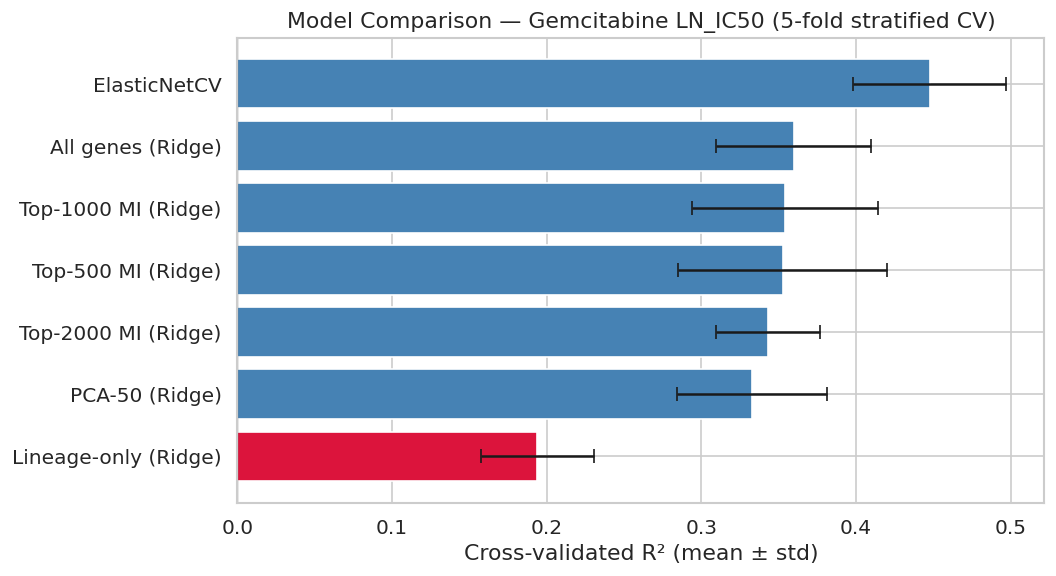

In [6]:
# Bar chart: pooled R2 with fold mean +/- std error bars
order_plot = comparison["model"].tolist()
r2_mean = [comparison.loc[comparison.model == m, "R2_mean"].iloc[0] for m in order_plot]
r2_std  = [comparison.loc[comparison.model == m, "R2_std"].iloc[0]  for m in order_plot]

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["crimson" if m.startswith("Lineage") else "steelblue" for m in order_plot]
ax.barh(order_plot[::-1], r2_mean[::-1], xerr=r2_std[::-1],
        color=colors[::-1], edgecolor="white", capsize=4)
ax.set_xlabel("Cross-validated R² (mean ± std)")
ax.set_title("Model Comparison — Gemcitabine LN_IC50 (5-fold stratified CV)")
ax.axvline(0, color="grey", lw=0.8)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "model_comparison_r2.png"), dpi=150, bbox_inches="tight")
plt.show()

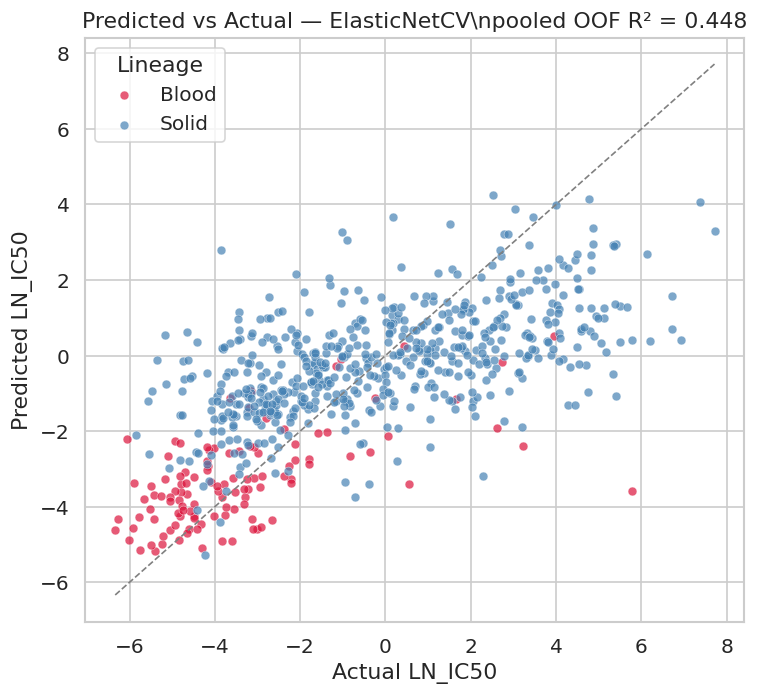

Best model: ElasticNetCV


In [7]:
# Predicted vs actual for the best model (pooled OOF), coloured by blood/solid
best_model = comparison.iloc[0]["model"]
pred = oof[best_model]
fig, ax = plt.subplots(figsize=(6.5, 6))
for flag, c, lbl in [(True, "crimson", "Blood"), (False, "steelblue", "Solid")]:
    mask = meta["is_blood"].values == flag
    ax.scatter(y[mask], pred[mask], s=28, alpha=0.7, color=c, edgecolors="white",
               linewidths=0.3, label=lbl)
lims = [min(y.min(), pred.min()), max(y.max(), pred.max())]
ax.plot(lims, lims, "--", color="grey", lw=1)
ax.set_xlabel("Actual LN_IC50"); ax.set_ylabel("Predicted LN_IC50")
ax.set_title(f"Predicted vs Actual — {best_model}\\npooled OOF R² = {r2_score(y, pred):.3f}")
ax.legend(title="Lineage")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "predicted_vs_actual_best.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Best model:", best_model)

---
## Section 5 — Performance by Lineage

Using the best model's out-of-fold predictions, we compute R² within each lineage. If the model
is merely exploiting the blood-cancer shortcut, solid-tumour lineages will have weak/negative R².

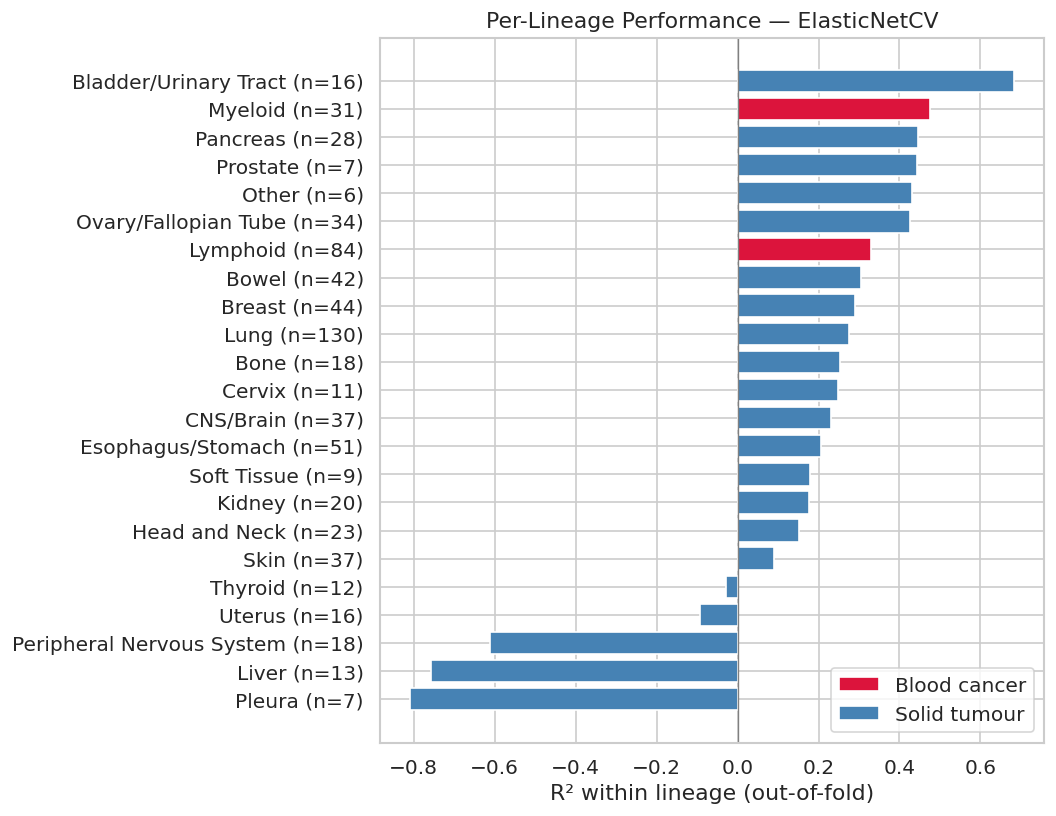

,lineage,n,R2,RMSE,is_blood
0,Bladder/Urinary Tract,16,0.6836,1.7186,False
1,Myeloid,31,0.4753,1.1421,True
2,Pancreas,28,0.4460,1.9475,False
3,Prostate,7,0.4440,1.2991,False
4,Other,6,0.4321,2.0798,False
5,Ovary/Fallopian Tube,34,0.4272,2.3613,False
6,Lymphoid,84,0.3306,1.9247,True
7,Bowel,42,0.3062,2.0605,False
8,Breast,44,0.2898,2.6843,False
9,Lung,130,0.2763,2.2643,False


In [8]:
best_pred = oof[best_model]
per_lineage = []
for lbl in sorted(meta["lineage_label"].unique()):
    mask = (meta["lineage_label"].values == lbl)
    if mask.sum() >= MIN_LINEAGE_COUNT:
        per_lineage.append({
            "lineage": lbl, "n": int(mask.sum()),
            "R2": r2_score(y[mask], best_pred[mask]),
            "RMSE": _rmse(y[mask], best_pred[mask]),
            "is_blood": lbl in BLOOD_LINEAGES,
        })
per_lineage = pd.DataFrame(per_lineage).sort_values("R2", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ["crimson" if b else "steelblue" for b in per_lineage["is_blood"]]
ax.barh(per_lineage["lineage"][::-1] + " (n=" + per_lineage["n"].astype(str)[::-1] + ")",
        per_lineage["R2"][::-1], color=colors[::-1], edgecolor="white")
ax.axvline(0, color="grey", lw=0.8)
ax.set_xlabel("R² within lineage (out-of-fold)")
ax.set_title(f"Per-Lineage Performance — {best_model}")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor="crimson", label="Blood cancer"),
                   Patch(facecolor="steelblue", label="Solid tumour")], loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "performance_by_lineage.png"), dpi=150, bbox_inches="tight")
plt.show()
per_lineage

---
## Section 6 — Solid-Tumour-Only Sensitivity Check

The decisive test for the confound: remove blood cancers and re-run. If genes still predict
within solid tumours, the model learned **mechanism**, not just *blood = sensitive*.

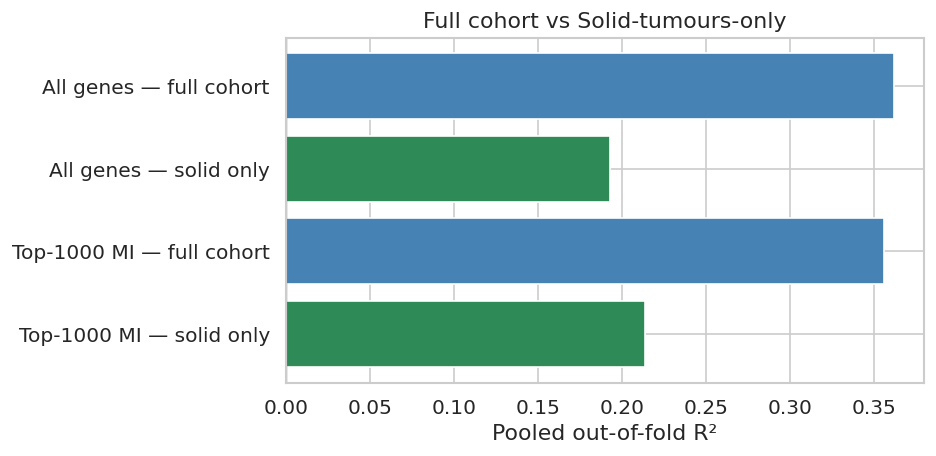

,setting,R2_pooled
0,All genes — full cohort,0.3620
1,All genes — solid only,0.1931
2,Top-1000 MI — full cohort,0.3558
3,Top-1000 MI — solid only,0.2137


In [9]:
solid = ~meta["is_blood"].values
Xs, ys = X[solid], y[solid]
lin_s  = collapse_rare(meta.loc[solid, "lineage_label"].values)   # recollapse for stratify
lin_s_enc = LabelEncoder().fit_transform(lin_s)

best_k = int([m.split("-")[1].split(" ")[0] for m in [best_model] if "MI" in best_model][0]) \
         if "MI" in best_model else KS[len(KS)//2]

def cv_eval(Xd, yd, strat, mode, k=None):
    skf2 = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_SEED)
    pred = np.full(len(yd), np.nan)
    for tr, te in skf2.split(Xd, strat):
        sc = StandardScaler().fit(Xd[tr])
        Xtr_s, Xte_s = sc.transform(Xd[tr]), sc.transform(Xd[te])
        if mode == "all":
            mdl = RidgeCV(alphas=RIDGE_ALPHAS).fit(Xtr_s, yd[tr])
            pred[te] = mdl.predict(Xte_s)
        else:  # top-k MI
            mi = mutual_info_regression(Xtr_s, yd[tr], random_state=RANDOM_SEED)
            idx = np.argsort(mi)[::-1][:k]
            mdl = RidgeCV(alphas=RIDGE_ALPHAS).fit(Xtr_s[:, idx], yd[tr])
            pred[te] = mdl.predict(Xte_s[:, idx])
    return r2_score(yd, pred)

res = {
    "All genes — full cohort":  r2_score(y, oof["All genes (Ridge)"]),
    "All genes — solid only":   cv_eval(Xs, ys, lin_s_enc, "all"),
    f"Top-{best_k} MI — full cohort": r2_score(y, oof[f"Top-{best_k} MI (Ridge)"]),
    f"Top-{best_k} MI — solid only":  cv_eval(Xs, ys, lin_s_enc, "topk", best_k),
}
solid_df = pd.DataFrame({"setting": list(res), "R2_pooled": list(res.values())})

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["steelblue" if "full" in s else "seagreen" for s in solid_df["setting"]]
ax.barh(solid_df["setting"][::-1], solid_df["R2_pooled"][::-1], color=colors[::-1], edgecolor="white")
ax.axvline(0, color="grey", lw=0.8)
ax.set_xlabel("Pooled out-of-fold R²")
ax.set_title("Full cohort vs Solid-tumours-only")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "solid_tumor_only_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()
solid_df

---
## Section 7 — Consensus Selected Genes & Biology Peek

For the best top-N model, which genes are selected consistently across folds? And do the known
Gemcitabine markers **DCK** / **SLC29A1** show up — or does multivariate selection still bury
them under lineage markers (as univariate Pearson did in notebook 02)?

In [10]:
sel_k = best_k if best_k in selected_idx else KS[len(KS)//2]
from collections import Counter
counter = Counter()
for idx in selected_idx[sel_k]:
    counter.update(idx.tolist())
consensus = pd.DataFrame(
    [(gene_names[i], cnt) for i, cnt in counter.items()],
    columns=["gene", "n_folds_selected"]
).sort_values("n_folds_selected", ascending=False).reset_index(drop=True)
consensus.to_csv(os.path.join(OUTPUT_DIR, "selected_genes_consensus.csv"), index=False)

print(f"Top-{sel_k} model — {len(consensus)} unique genes selected across folds; "
      f"{(consensus['n_folds_selected'] == N_SPLITS).sum()} in all {N_SPLITS} folds.")

for marker in ["DCK", "SLC29A1"]:
    hit = consensus[consensus["gene"].str.startswith(marker + " ")]
    if len(hit):
        print(f"  {marker}: selected in {hit.iloc[0]['n_folds_selected']}/{N_SPLITS} folds")
    else:
        print(f"  {marker}: not in selected set (lineage signal dominates MI)")

consensus.head(20)

Top-1000 model — 2436 unique genes selected across folds; 203 in all 5 folds.
  DCK: selected in 2/5 folds
  SLC29A1: not in selected set (lineage signal dominates MI)


,gene,n_folds_selected
0,ARHGAP30 (257106),5
1,TSPAN6 (7105),5
2,TJP1 (7082),5
3,ITGAV (3685),5
4,NIBAN2 (64855),5
5,CUEDC1 (404093),5
6,NOS1AP (9722),5
7,CD276 (80381),5
8,LURAP1L (286343),5
9,DYNLT1 (6993),5


---
## Summary & Next Steps

**Read the results table + plots in `output/` to interpret:**
- `model_comparison.csv` / `model_comparison_r2.png` — does any gene model beat the
  lineage-only baseline? By how much?
- `performance_by_lineage.png` — is performance broad, or driven by blood cancers?
- `solid_tumor_only_comparison.png` — does R² survive when blood cancers are removed?
- `selected_genes_consensus.csv` — stable genes; whether DCK/SLC29A1 surface.

**Persisted for notebooks 04–05:** `X_var_filtered.npy`, `y.npy`, `gene_names.json`,
`meta.csv`, `cv_folds.npz`, `holdout_split.npz`, `selected_genes_consensus.csv`.

**Next:** notebook 04 trains the PyTorch MLP on the best representation, reusing these exact
splits, and asks whether deep learning beats the regularized linear baseline on n=694.